In [12]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import sys
import os

# Add preprocessing folder to path
sys.path.append(os.path.abspath("../data_preprocessing"))

from patch_utils import extract_patch

In [13]:
base_path = "../data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/"

flair = nib.load(base_path + "BraTS20_Training_001_flair.nii").get_fdata()
t1 = nib.load(base_path + "BraTS20_Training_001_t1.nii").get_fdata()
t1ce = nib.load(base_path + "BraTS20_Training_001_t1ce.nii").get_fdata()
t2 = nib.load(base_path + "BraTS20_Training_001_t2.nii").get_fdata()
seg = nib.load(base_path + "BraTS20_Training_001_seg.nii").get_fdata()

print("Loaded shapes:", flair.shape)

Loaded shapes: (240, 240, 155)


In [14]:
def normalize(volume):
    
    mask = volume > 0  # ignore background
    
    mean = volume[mask].mean()
    std = volume[mask].std()
    
    if std == 0:
        std = 1
    
    volume[mask] = (volume[mask] - mean) / std
    
    return volume

In [15]:
flair_n = normalize(flair.copy())
t1_n = normalize(t1.copy())
t1ce_n = normalize(t1ce.copy())
t2_n = normalize(t2.copy())

In [16]:
# Find tumor voxels
tumor_voxels = np.where(seg > 0)
x, y, z = tumor_voxels

# Tumor center
cx = x[len(x)//2]
cy = y[len(y)//2]
cz = z[len(z)//2]

# Patch size
size = 128
half = size // 2

# Extract patches
flair_patch = flair_n[cx-half:cx+half, cy-half:cy+half, cz-half:cz+half]
t1_patch    = t1_n[cx-half:cx+half, cy-half:cy+half, cz-half:cz+half]
t1ce_patch  = t1ce_n[cx-half:cx+half, cy-half:cy+half, cz-half:cz+half]
t2_patch    = t2_n[cx-half:cx+half, cy-half:cy+half, cz-half:cz+half]

seg_patch   = seg[cx-half:cx+half, cy-half:cy+half, cz-half:cz+half]

print("Patch shape:", flair_patch.shape)

Patch shape: (128, 128, 128)


In [17]:
multi_patch = np.stack([
    flair_patch,
    t1_patch,
    t1ce_patch,
    t2_patch
], axis=0)

print("Multi-modal shape:", multi_patch.shape)

Multi-modal shape: (4, 128, 128, 128)


In [18]:
print("Mean:", multi_patch.mean())
print("Std:", multi_patch.std())

Mean: 0.03377832325198122
Std: 0.7188517698296908


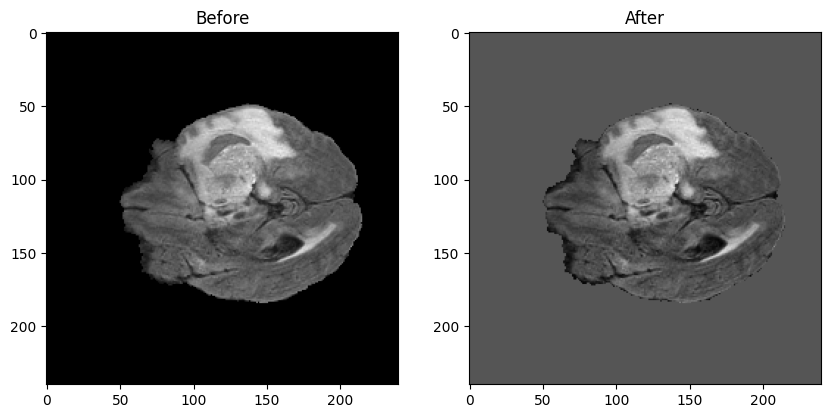

In [19]:
slice_index = 64

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(flair[:, :, slice_index], cmap="gray")
plt.title("Before")

plt.subplot(1,2,2)
plt.imshow(flair_n[:, :, slice_index], cmap="gray")
plt.title("After")

plt.show()

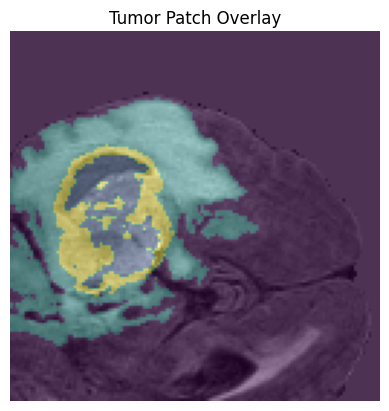

In [20]:
slice_index = seg_patch.shape[2] // 2

plt.imshow(flair_patch[:, :, slice_index], cmap="gray")
plt.imshow(seg_patch[:, :, slice_index], alpha=0.4)

plt.title("Tumor Patch Overlay")
plt.axis("off")
plt.show()